# Decision Tree - Árvore de Decisão

## O que é uma Decision Tree?

Uma **Decision Tree** é um algoritmo de aprendizagem supervisionado utilizado para tarefas de **classificação** e **regressão**.

Chama-se Decision Tree devido à sua estrutura hierárquica em árvore que consiste em:
- **Nó raiz (root node)**: Ponto inicial da árvore
- **Ramificações (branches)**: Conexões entre nós
- **Nós internos (internal nodes)**: Nós de decisão
- **Nós folha (leaf nodes)**: Nós terminais com os resultados finais

### Como funciona?

1. A Decision Tree começa no **nó raiz**, que não possui ramificações de entrada
2. Origina várias ramificações de saída que conduzem aos **nós internos** (nós de decisão)
3. Estes nós analisam características/atributos do dataset e realizam avaliações
4. Os dados são divididos em subconjuntos cada vez mais homogéneos
5. Chegamos aos **nós folha** (terminais) que representam o resultado final

### Exemplo prático: Decidir se fazer surf

```
                    Is there a swell?
                    /              \
                  Yes               No
                  /                  \
           High wind?            Don't surf
           /        \
         Yes        No
          |          |
    Onshore wind  Offshore wind
          |          |
    Don't surf     Surf
```

## Dataset IRIS

O **Iris Dataset** é um dos conjuntos de dados mais conhecidos em machine learning.

### História
- Introduzido em **1936** por **Ronald Fisher**, estatístico britânico
- Fundamental no desenvolvimento da estatística moderna
- Popular por ser simples, bem estruturado e educativo

### Características do Dataset

- **150 observações** de flores
- **3 espécies** diferentes (50 amostras cada):
  - Iris setosa
  - Iris versicolor
  - Iris virginica

### Atributos (Features)

Para cada flor são registadas 4 características físicas (em centímetros):
1. **Comprimento da sépala** (sepal length)
2. **Largura da sépala** (sepal width)
3. **Comprimento da pétala** (petal length)
4. **Largura da pétala** (petal width)

**Nota:** A sépala é a parte exterior da flor, enquanto a pétala é a parte mais visível e colorida.

### Utilização
- Aprender conceitos básicos de Machine Learning
- Testar algoritmos de classificação
- Demonstrar técnicas de análise de dados
- Criar visualizações de dados

## Implementação Prática



In [1]:
# Importar bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

### 1. Carregar o Dataset IRIS

In [2]:
# Carregar o dataset
iris = load_iris()

# Criar um DataFrame para melhor visualização
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas do dataset:")
df.head(10)

Dimensões do dataset: (150, 6)

Primeiras linhas do dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [3]:
# Informações estatísticas do dataset
print("Estatísticas descritivas:")
df.describe()

Estatísticas descritivas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Distribuição das espécies:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


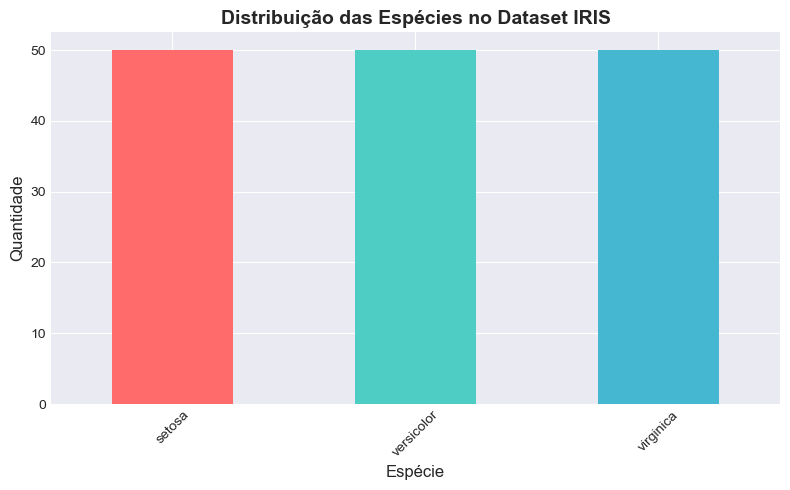

In [4]:
# Distribuição das espécies
print("Distribuição das espécies:")
print(df['species_name'].value_counts())

# Visualizar a distribuição
plt.figure(figsize=(8, 5))
df['species_name'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Distribuição das Espécies no Dataset IRIS', fontsize=14, fontweight='bold')
plt.xlabel('Espécie', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Visualização dos Dados

<Figure size 1200x1000 with 0 Axes>

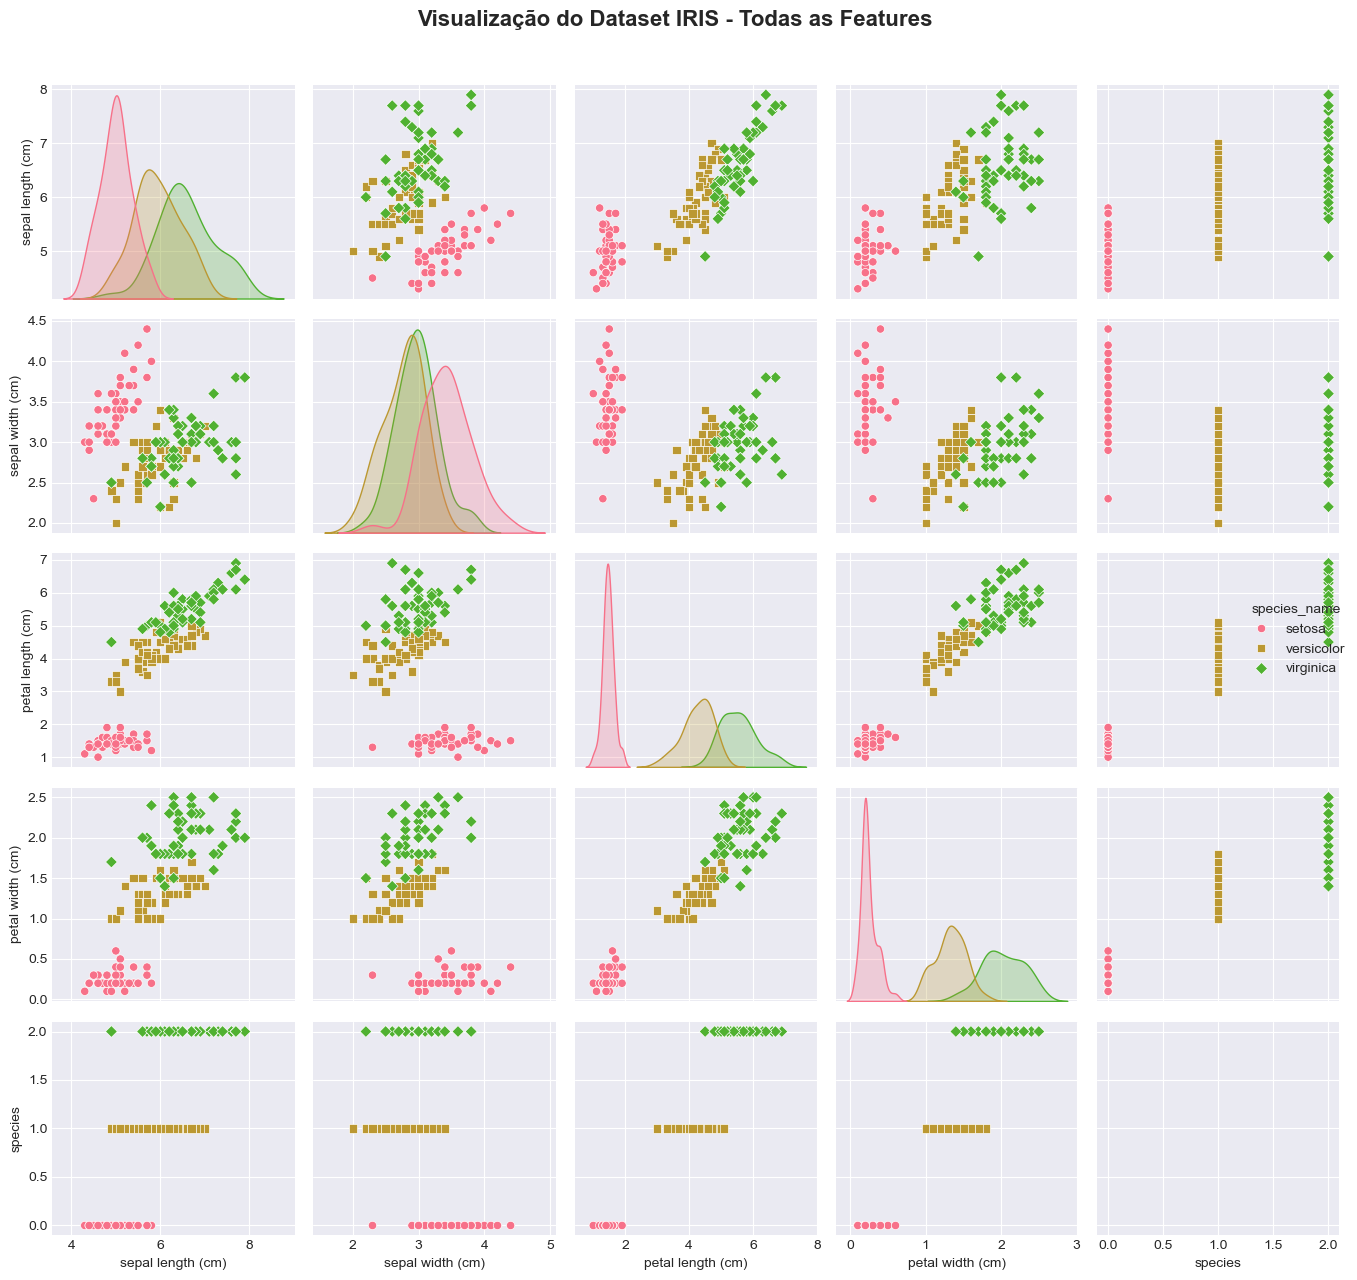

In [5]:
# Pairplot - Visualização de todas as features
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='species_name', markers=['o', 's', 'D'])
plt.suptitle('Visualização do Dataset IRIS - Todas as Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

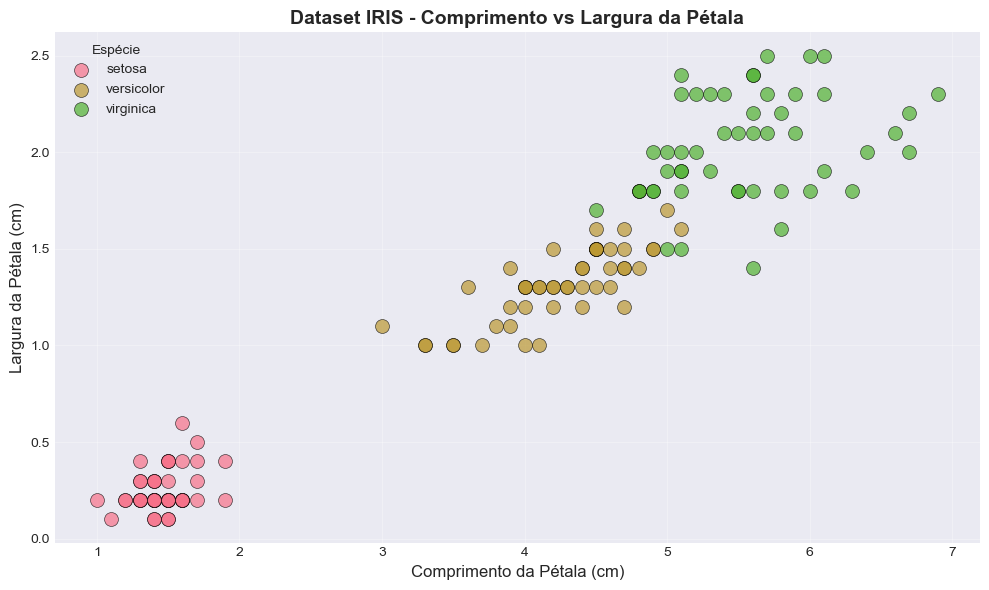

Observação: A espécie setosa forma um grupo separado,
enquanto versicolor e virginica apresentam alguma sobreposição.


In [6]:
# Scatter plot específico: Comprimento vs Largura da Pétala
plt.figure(figsize=(10, 6))
for species in df['species_name'].unique():
    subset = df[df['species_name'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                label=species, alpha=0.7, s=100, edgecolors='black', linewidth=0.5)

plt.xlabel('Comprimento da Pétala (cm)', fontsize=12)
plt.ylabel('Largura da Pétala (cm)', fontsize=12)
plt.title('Dataset IRIS - Comprimento vs Largura da Pétala', fontsize=14, fontweight='bold')
plt.legend(title='Espécie', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observação: A espécie setosa forma um grupo separado,")
print("enquanto versicolor e virginica apresentam alguma sobreposição.")

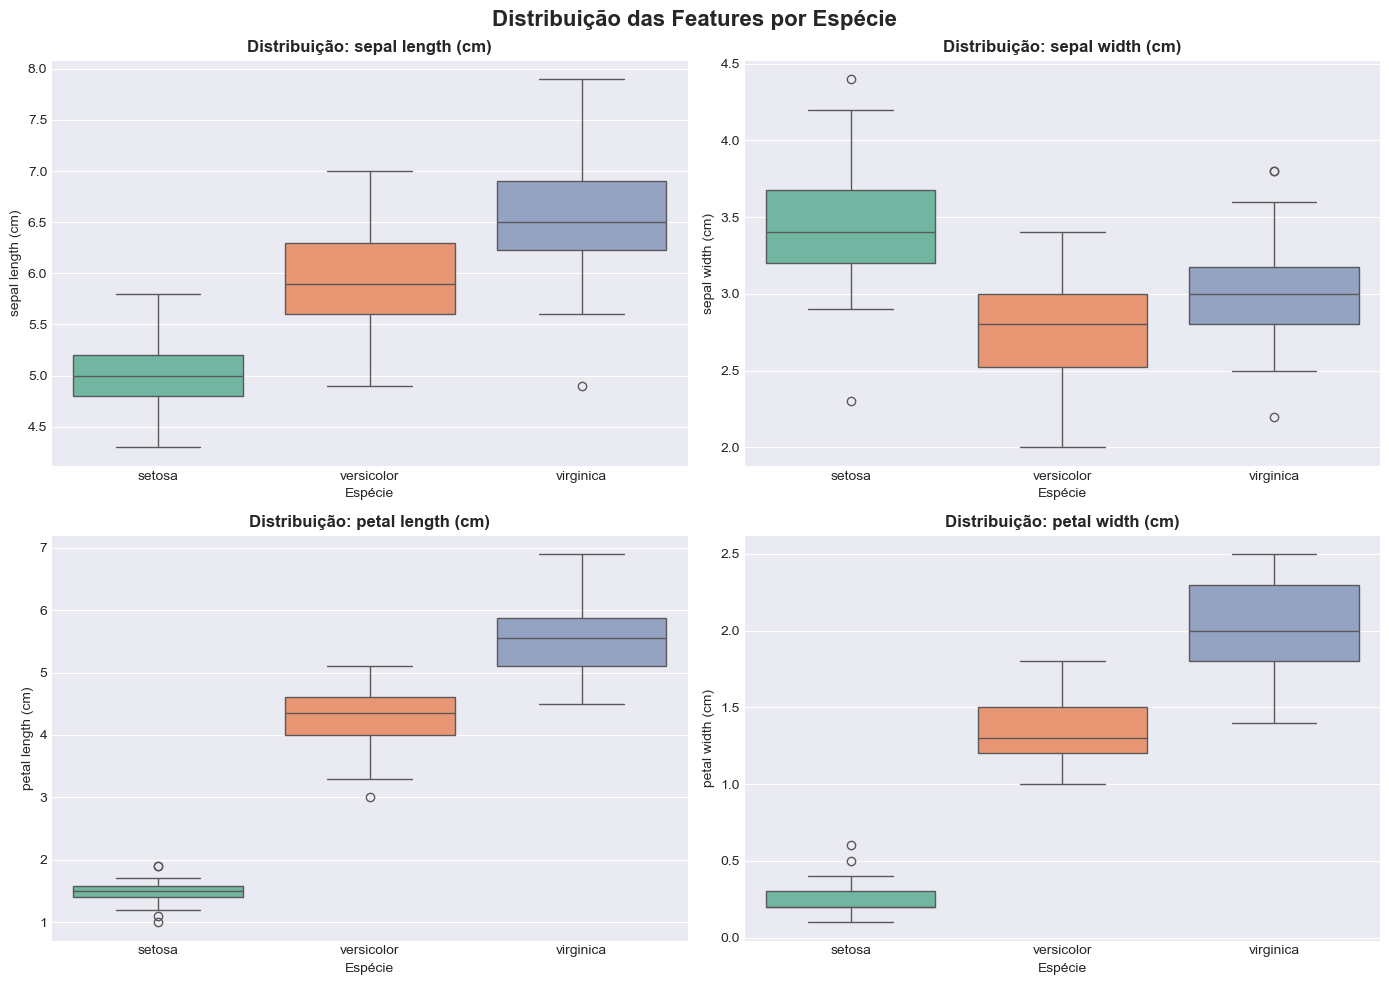

In [7]:
# Boxplot para visualizar a distribuição de cada feature por espécie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = iris.feature_names

for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    sns.boxplot(
        data=df,
        x='species_name',
        y=feature,
        hue='species_name',
        palette='Set2',
        legend=False,
        dodge=False,
        ax=axes[row, col]
    )
    axes[row, col].set_title(f'Distribuição: {feature}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Espécie', fontsize=10)
    axes[row, col].set_ylabel(feature, fontsize=10)

plt.suptitle('Distribuição das Features por Espécie', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Preparar os Dados para Treino

In [8]:
# Separar features (X) e target (y)
X = iris.data
y = iris.target

# Dividir em conjunto de treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição no conjunto de treino:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nDistribuição no conjunto de teste:")
print(pd.Series(y_test).value_counts().sort_index())

Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de teste: 30 amostras

Distribuição no conjunto de treino:
0    40
1    40
2    40
Name: count, dtype: int64

Distribuição no conjunto de teste:
0    10
1    10
2    10
Name: count, dtype: int64


### 4. Criar e Treinar a Decision Tree

In [9]:
# Criar o modelo de Decision Tree
dt_classifier = DecisionTreeClassifier(
    criterion='gini',      # Métrica de impureza (pode ser 'gini' ou 'entropy')
    max_depth=3,           # Profundidade máxima da árvore
    min_samples_split=2,   # Número mínimo de amostras para dividir um nó
    min_samples_leaf=1,    # Número mínimo de amostras em um nó folha
    random_state=42
)

# Treinar o modelo
dt_classifier.fit(X_train, y_train)

print("✓ Modelo treinado com sucesso!")
print(f"Profundidade da árvore: {dt_classifier.get_depth()}")
print(f"Número de folhas: {dt_classifier.get_n_leaves()}")

✓ Modelo treinado com sucesso!
Profundidade da árvore: 3
Número de folhas: 5


### 5. Visualizar a Decision Tree

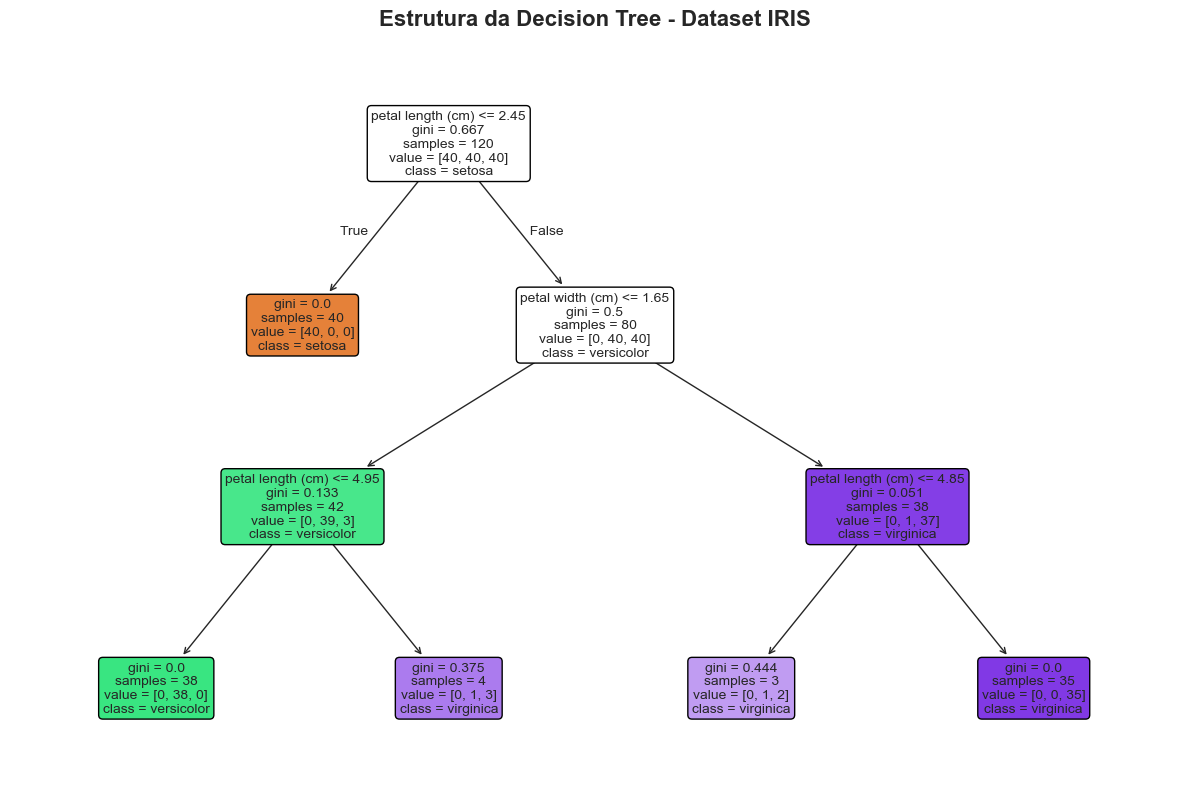

In [18]:
# Visualizar a estrutura da árvore
plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Estrutura da Decision Tree - Dataset IRIS', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 6. Fazer Previsões

In [11]:
# Fazer previsões no conjunto de teste
y_pred = dt_classifier.predict(X_test)

# Comparar algumas previsões com os valores reais
comparison_df = pd.DataFrame({
    'Real': [iris.target_names[i] for i in y_test[:10]],
    'Previsto': [iris.target_names[i] for i in y_pred[:10]],
    'Correto': ['✓' if y_test[i] == y_pred[i] else '✗' for i in range(10)]
})

print("Primeiras 10 previsões:")
print(comparison_df.to_string(index=False))

Primeiras 10 previsões:
      Real   Previsto Correto
    setosa     setosa       ✓
 virginica  virginica       ✓
versicolor versicolor       ✓
versicolor versicolor       ✓
    setosa     setosa       ✓
versicolor versicolor       ✓
    setosa     setosa       ✓
    setosa     setosa       ✓
 virginica  virginica       ✓
versicolor versicolor       ✓


### 7. Avaliar o Desempenho do Modelo

In [12]:
# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2%}")
print(f"\nErros: {np.sum(y_test != y_pred)} de {len(y_test)} previsões")

Acurácia do modelo: 96.67%

Erros: 1 de 30 previsões


In [13]:
# Relatório de classificação detalhado
print("\nRelatório de Classificação:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



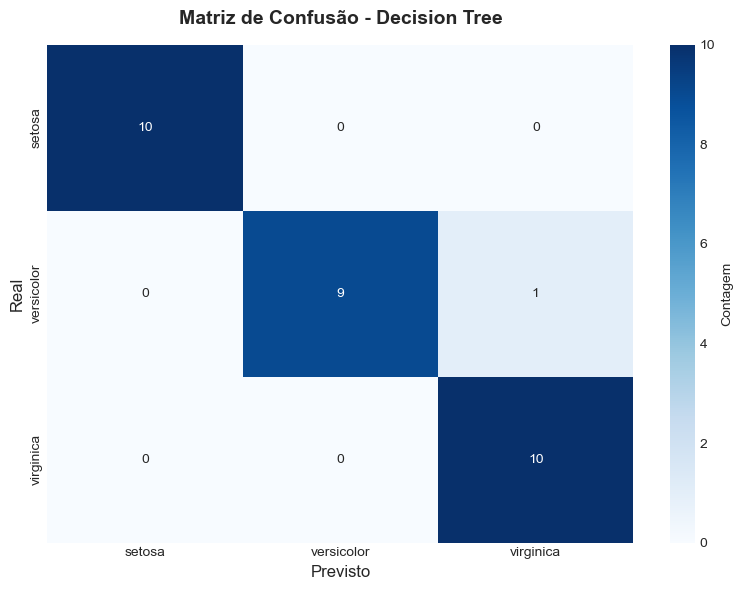

In [14]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names,
            cbar_kws={'label': 'Contagem'})
plt.title('Matriz de Confusão - Decision Tree', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

### 8. Importância das Features

Importância das Features:
          Feature  Importância
petal length (cm)     0.579077
 petal width (cm)     0.420923
sepal length (cm)     0.000000
 sepal width (cm)     0.000000


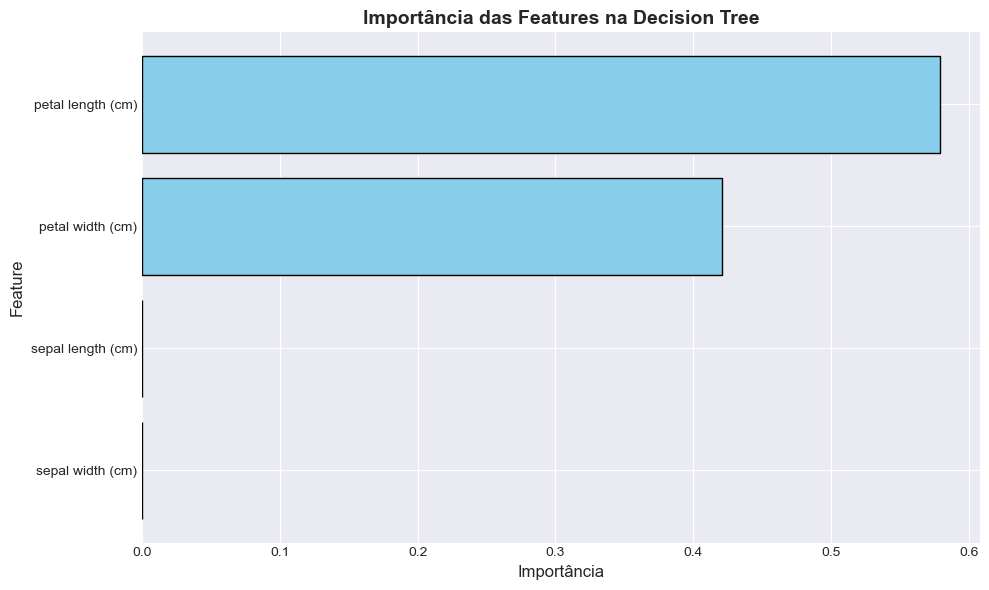

In [15]:
# Obter a importância de cada feature
feature_importance = dt_classifier.feature_importances_

# Criar DataFrame para melhor visualização
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importância': feature_importance
}).sort_values('Importância', ascending=False)

print("Importância das Features:")
print(importance_df.to_string(index=False))

# Visualizar a importância
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importância'], color='skyblue', edgecolor='black')
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Importância das Features na Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 9. Testar com Novos Dados

In [16]:
# Criar uma nova amostra para previsão
# [sepal length, sepal width, petal length, petal width]
nova_flor = np.array([[5.1, 3.5, 1.4, 0.2]])  # Características típicas de setosa

# Fazer previsão
previsao = dt_classifier.predict(nova_flor)
probabilidades = dt_classifier.predict_proba(nova_flor)

print("Nova flor com características:")
print(f"  Comprimento da sépala: {nova_flor[0][0]} cm")
print(f"  Largura da sépala: {nova_flor[0][1]} cm")
print(f"  Comprimento da pétala: {nova_flor[0][2]} cm")
print(f"  Largura da pétala: {nova_flor[0][3]} cm")
print(f"\n✓ Previsão: {iris.target_names[previsao[0]]}")
print(f"\nProbabilidades:")
for i, species in enumerate(iris.target_names):
    print(f"  {species}: {probabilidades[0][i]:.2%}")

Nova flor com características:
  Comprimento da sépala: 5.1 cm
  Largura da sépala: 3.5 cm
  Comprimento da pétala: 1.4 cm
  Largura da pétala: 0.2 cm

✓ Previsão: setosa

Probabilidades:
  setosa: 100.00%
  versicolor: 0.00%
  virginica: 0.00%


## Conclusões

### Vantagens da Decision Tree:
- ✓ Fácil de entender e interpretar
- ✓ Visualização intuitiva da estrutura de decisão
- ✓ Não requer normalização dos dados
- ✓ Capaz de lidar com dados numéricos e categóricos
- ✓ Mostra a importância de cada feature

### Desvantagens:
- ✗ Pode sofrer de overfitting (sobreajuste)
- ✗ Pequenas mudanças nos dados podem resultar em árvores muito diferentes
- ✗ Pode criar árvores enviesadas se algumas classes dominarem

### Observações sobre o Dataset IRIS:
- A espécie **setosa** é facilmente separável das outras
- As espécies **versicolor** e **virginica** apresentam alguma sobreposição
- As características das **pétalas** são mais importantes que as das **sépalas** para a classificação